# Validação técnica — classificação de inadimplência

## tl;dr

- Base estruturalmente íntegra: 30,000 registros, 22.12% positivos, sem missing e sem duplicatas exatas.
- Benchmark: Random Forest AP 0.5294, Gradient Boosting 0.5426 e XGBoost 0.5476; o ganho do XGBoost é pequeno.
- Optuna escolheu o Gradient Boosting (trial 14) e elevou AP de 0.5426 para 0.5539 (2.08% relativo), com custo de treino maior.
- Balanceamento final: Original. SMOTENC e pesos não melhoraram o ranking o suficiente para justificar complexidade adicional.
- Threshold pedagógico: 0.27; na validação, precision 0.521, recall 0.560 e F1 0.540.
- Self-training: APENAS DEMONSTRAÇÃO; delta de AP -0.003967, com pseudorrótulos concentrados na classe 0.
- Teste final aberto uma única vez: precision 0.525, recall 0.557, F1 0.541, ROC-AUC 0.778 e AP/PR-AUC 0.554.
- Principais features por Permutation Importance: PAY_0, LIMIT_BAL, PAY_2, BILL_AMT1, PAY_3. Importância preditiva não é causal.
- Recomendação: Gradient Boosting otimizado no pipeline final; Random Forest para Bagging, XGBoost como comparação avançada e Self-training apenas como demonstração curta.


## Contexto e métodos

Objetivo: verificar, com evidência reproduzível, qual sequência de classificação avançada é tecnicamente correta, simples e pedagogicamente útil para o curso.

Fonte: [Default of Credit Card Clients — UCI](https://archive.ics.uci.edu/dataset/350/default). A base descreve 30 mil clientes de cartão em Taiwan, com histórico mensal de abril a setembro de 2005 e target binário de inadimplência no mês seguinte.

### Premissas e limites

- Unidade inferida: uma linha por cliente/conta, identificada por `ID`; não há chave natural para confirmar pessoa única.
- `ID` é excluído das features por ser identificador sequencial e possível proxy de ordem/coorte.
- `SEX`, `EDUCATION` e `MARRIAGE` são nominais. Códigos não documentados são preservados como níveis distintos, sem correção silenciosa.
- `PAY_*` é mantido como ordinal numérico. Os códigos `-2` e `0` não são explicados pelo dicionário oficial atual; isso permanece como caveat.
- Faturas negativas e valores extremos não são truncados: podem refletir saldo credor ou caudas reais.
- Não há datas por linha para provar o cutoff temporal. O split aleatório serve ao benchmark pedagógico, não comprova validade futura.
- Não existem tratamento, controle, exposição, custos ou receita. Esta análise é descritiva/preditiva; causalidade, uplift e ROI não são identificáveis.
- `PR-AUC` é operacionalizada por `average_precision_score` e reportada como **AP/PR-AUC**.

## 1. Carregamento e auditoria

### 1.1 Ambiente e parâmetros reproduzíveis

In [1]:
from __future__ import annotations

from io import BytesIO
from pathlib import Path
import hashlib
import json
import platform
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import sklearn
import xgboost
import imblearn

from IPython.display import Markdown, display
from imblearn.over_sampling import SMOTENC
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = "default.payment.next.month"
NOMINAL_COLUMNS = ["SEX", "EDUCATION", "MARRIAGE"]
PAYMENT_STATUS_COLUMNS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "raw" / "UCI_Credit_Card.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "UCI_Credit_Card.csv"

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "font.size": 10,
})
BLUE = "#1F5A7A"
ORANGE = "#D97706"
CHARCOAL = "#263238"
LIGHT_BLUE = "#9EC5D9"
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
optuna.logging.set_verbosity(optuna.logging.WARNING)

versions = pd.Series({
    "Python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit-learn": sklearn.__version__,
    "xgboost": xgboost.__version__,
    "imbalanced-learn": imblearn.__version__,
    "optuna": optuna.__version__,
    "joblib": joblib.__version__,
}, name="versão")
versions.to_frame()

,versão
Python,3.11.9
pandas,3.0.3
numpy,2.4.6
scikit-learn,1.9.0
xgboost,3.2.0
imbalanced-learn,0.14.2
optuna,4.9.0
joblib,1.5.3


### 1.2 Leitura imutável e contrato básico

O arquivo bruto é apenas lido. O hash permite confirmar exatamente qual cópia sustentou os resultados.

In [2]:
assert DATA_PATH.exists(), f"Base não encontrada: {DATA_PATH}"
raw_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
data = pd.read_csv(DATA_PATH)

print(f"Arquivo: {DATA_PATH}")
print(f"SHA-256: {raw_sha256}")
print(f"Dimensões: {data.shape[0]:,} linhas x {data.shape[1]} colunas")
data.head(3)

Arquivo: C:\GitHub\ALURA-TESTE\classificacao-avancando-classificadores\data\raw\UCI_Credit_Card.csv
SHA-256: a0f0ab49d6326671d6cd83be5c88dcf18007025fe9a53ecd699119c871176ca1
Dimensões: 30,000 linhas x 25 colunas


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,"20,000.0000",2,2,1,24,2,2,-1,-1,-2,-2,"3,913.0000","3,102.0000",689.0000,0.0000,0.0000,0.0000,0.0000,689.0000,0.0000,0.0000,0.0000,0.0000,1
1,2,"120,000.0000",2,2,2,26,-1,2,0,0,0,2,"2,682.0000","1,725.0000","2,682.0000","3,272.0000","3,455.0000","3,261.0000",0.0000,"1,000.0000","1,000.0000","1,000.0000",0.0000,"2,000.0000",1
2,3,"90,000.0000",2,2,2,34,0,0,0,0,0,0,"29,239.0000","14,027.0000","13,559.0000","14,331.0000","14,948.0000","15,549.0000","1,518.0000","1,500.0000","1,000.0000","1,000.0000","1,000.0000","5,000.0000",0


In [3]:
required_columns = {"ID", TARGET}
assert required_columns.issubset(data.columns)
assert set(data[TARGET].unique()) == {0, 1}

missing_cells = int(data.isna().sum().sum())
exact_duplicates = int(data.duplicated().sum())
id_duplicates = int(data["ID"].duplicated().sum())
duplicates_without_id = int(data.drop(columns="ID").duplicated().sum())
duplicates_features_only = int(data.drop(columns=["ID", TARGET]).duplicated().sum())

quality_summary = pd.DataFrame({
    "checagem": [
        "Linhas", "Colunas", "Células ausentes", "Duplicatas exatas",
        "IDs duplicados", "Duplicatas sem ID (inclui target)",
        "Duplicatas só de features", "ID mínimo", "ID máximo",
    ],
    "resultado": [
        len(data), data.shape[1], missing_cells, exact_duplicates,
        id_duplicates, duplicates_without_id, duplicates_features_only,
        int(data["ID"].min()), int(data["ID"].max()),
    ],
})
quality_summary

,checagem,resultado
0,Linhas,30000
1,Colunas,25
2,Células ausentes,0
3,Duplicatas exatas,0
4,IDs duplicados,0
5,Duplicatas sem ID (inclui target),35
6,Duplicatas só de features,56
7,ID mínimo,1
8,ID máximo,30000


In [4]:
profile = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "cardinalidade": data.nunique(dropna=False),
    "mínimo": data.min(numeric_only=True),
    "máximo": data.max(numeric_only=True),
})
profile

,dtype,missing,cardinalidade,mínimo,máximo
ID,int64,0,30000,1.0000,"30,000.0000"
LIMIT_BAL,float64,0,81,"10,000.0000","1,000,000.0000"
SEX,int64,0,2,1.0000,2.0000
EDUCATION,int64,0,7,0.0000,6.0000
MARRIAGE,int64,0,4,0.0000,3.0000
AGE,int64,0,56,21.0000,79.0000
PAY_0,int64,0,11,-2.0000,8.0000
PAY_2,int64,0,11,-2.0000,8.0000
PAY_3,int64,0,11,-2.0000,8.0000
PAY_4,int64,0,11,-2.0000,8.0000


### 1.3 Categorias numéricas e códigos fora do dicionário

Os códigos são registrados antes de qualquer decisão. Não há remapeamento nesta prova técnica.

In [5]:
official_nominal_codes = {
    "SEX": {1, 2},
    "EDUCATION": {1, 2, 3, 4},
    "MARRIAGE": {1, 2, 3},
}
category_rows = []
for column, documented in official_nominal_codes.items():
    observed = set(data[column].unique())
    undocumented = sorted(observed - documented)
    category_rows.append({
        "feature": column,
        "valores_observados": sorted(observed),
        "fora_do_dicionário": undocumented,
        "n_fora": int(data[column].isin(undocumented).sum()),
        "percentual_fora": data[column].isin(undocumented).mean(),
    })

category_audit = pd.DataFrame(category_rows)
category_audit

,feature,valores_observados,fora_do_dicionário,n_fora,percentual_fora
0,SEX,"[1, 2]",[],0,0.0000
1,EDUCATION,"[0, 1, 2, 3, 4, 5, 6]","[0, 5, 6]",345,0.0115
2,MARRIAGE,"[0, 1, 2, 3]",[0],54,0.0018


In [6]:
payment_status_audit = pd.DataFrame({
    column: data[column].value_counts().sort_index()
    for column in PAYMENT_STATUS_COLUMNS
}).fillna(0).astype(int)
payment_status_audit.index.name = "código"
payment_status_audit

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
código,,,,,,
-2,2759,3782,4085,4348,4546,4895
-1,5686,6050,5938,5687,5539,5740
0,14737,15730,15764,16455,16947,16286
1,3688,28,4,2,0,0
2,2667,3927,3819,3159,2626,2766
3,322,326,240,180,178,184
4,76,99,76,69,84,49
5,26,25,21,35,17,13
6,11,12,23,5,4,19


In [7]:
monetary_columns = ["LIMIT_BAL"] + [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
range_audit = data[monetary_columns + ["AGE"]].agg(["min", "median", "max"]).T
range_audit["negativos"] = (data[range_audit.index] < 0).sum()
range_audit["zeros"] = (data[range_audit.index] == 0).sum()
range_audit

,min,median,max,negativos,zeros
LIMIT_BAL,"10,000.0000","140,000.0000","1,000,000.0000",0,0
BILL_AMT1,"-165,580.0000","22,381.5000","964,511.0000",590,2008
BILL_AMT2,"-69,777.0000","21,200.0000","983,931.0000",669,2506
BILL_AMT3,"-157,264.0000","20,088.5000","1,664,089.0000",655,2870
BILL_AMT4,"-170,000.0000","19,052.0000","891,586.0000",675,3195
BILL_AMT5,"-81,334.0000","18,104.5000","927,171.0000",655,3506
BILL_AMT6,"-339,603.0000","17,071.0000","961,664.0000",688,4020
PAY_AMT1,0.0000,"2,100.0000","873,552.0000",0,5249
PAY_AMT2,0.0000,"2,009.0000","1,684,259.0000",0,5396
PAY_AMT3,0.0000,"1,800.0000","896,040.0000",0,5968


### 1.4 Distribuição do outcome

In [8]:
target_distribution = (
    data[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis("classe")
    .to_frame("registros")
)
target_distribution["proporção"] = target_distribution["registros"] / len(data)
target_distribution

,registros,proporção
classe,,
0,23364,0.7788
1,6636,0.2212


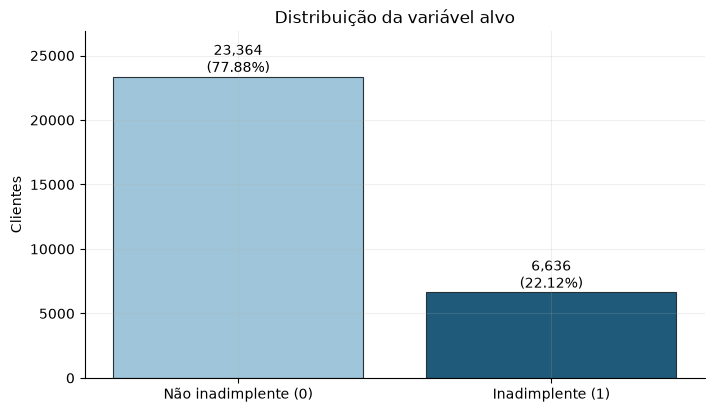

In [9]:
fig, ax = plt.subplots()
labels = ["Não inadimplente (0)", "Inadimplente (1)"]
values = target_distribution["registros"].to_numpy()
bars = ax.bar(labels, values, color=[LIGHT_BLUE, BLUE], edgecolor=CHARCOAL, linewidth=0.8)
ax.set_title("Distribuição da variável alvo")
ax.set_ylabel("Clientes")
ax.set_ylim(0, values.max() * 1.15)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, value, f"{value:,}\n({value/len(data):.2%})", ha="center", va="bottom")
plt.show()

### Gate de qualidade antes da modelagem

- Granularidade: uma linha por `ID`; a chave é única.
- Outcome: inadimplência no mês seguinte (`1`) versus não inadimplência (`0`).
- Tratamento/controle: não aplicável; não há desenho causal.
- Datas: ausentes por linha; a documentação informa meses de 2005, mas o cutoff não pode ser auditado individualmente.
- Leakage: `ID` é removido. As demais features são históricas segundo a documentação, com caveat temporal explícito.
- Decisão conservadora: manter códigos e caudas, sem imputação, deduplicação, clipping ou engenharia extensa.

## 2. Definição de features e target

In [10]:
feature_columns = [column for column in data.columns if column not in ["ID", TARGET]]
X = data[feature_columns].copy()
y = data[TARGET].copy()

assert "ID" not in X.columns
assert TARGET not in X.columns
assert len(feature_columns) == 23
print(f"Features: {len(feature_columns)}")
print(f"Target: {TARGET}")

Features: 23
Target: default.payment.next.month


## 3. Treino, validação e teste protegido

A divisão ocorre em duas etapas estratificadas: 80/20 para reservar o teste e, depois, 75/25 dentro dos 80% restantes. Isso produz 60/20/20. O teste abaixo é apenas contado; nenhuma predição ou métrica é calculada até o congelamento das decisóes.

In [11]:
X_train_validation, X_test, y_train_validation, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_validation, y_train_validation,
    test_size=0.25,
    stratify=y_train_validation,
    random_state=RANDOM_STATE,
)

test_is_locked = True
split_summary = pd.DataFrame({
    "conjunto": ["Treino", "Validação", "Teste protegido"],
    "registros": [len(X_train), len(X_validation), len(X_test)],
    "positivos": [int(y_train.sum()), int(y_validation.sum()), int(y_test.sum())],
    "proporção_positiva": [y_train.mean(), y_validation.mean(), y_test.mean()],
})

assert len(set(X_train.index) & set(X_validation.index)) == 0
assert len(set(X_train.index) & set(X_test.index)) == 0
assert len(set(X_validation.index) & set(X_test.index)) == 0
assert split_summary["registros"].sum() == len(data)
split_summary

,conjunto,registros,positivos,proporção_positiva
0,Treino,18000,3982,0.2212
1,Validação,6000,1327,0.2212
2,Teste protegido,6000,1327,0.2212


## 4. Benchmark

### 4.1 Preprocessamentos explícitos

- Logística: one-hot nas três variáveis nominais e padronização nas demais.
- árvores/ensembles: mesmo one-hot nominal, sem escalonamento.
- `handle_unknown="ignore"` evita falha quando um nível raro aparece fora do treino.

In [12]:
numeric_and_ordinal_columns = [column for column in feature_columns if column not in NOMINAL_COLUMNS]

logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("nominal", OneHotEncoder(handle_unknown="ignore", sparse_output=False), NOMINAL_COLUMNS),
        ("numeric_ordinal", StandardScaler(), numeric_and_ordinal_columns),
    ],
    verbose_feature_names_out=False,
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("nominal", OneHotEncoder(handle_unknown="ignore", sparse_output=False), NOMINAL_COLUMNS),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

def make_logistic_pipeline():
    return Pipeline([
        ("preprocess", clone(logistic_preprocessor)),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])

def make_gradient_pipeline(model_params=None):
    params = dict(model_params or {})
    params["random_state"] = RANDOM_STATE
    return Pipeline([
        ("preprocess", clone(tree_preprocessor)),
        ("model", GradientBoostingClassifier(**params)),
    ])

### 4.2 Métricas uniformes

Precision, Recall e F1 dependem do threshold. ROC-AUC e AP/PR-AUC usam probabilidades e não mudam quando apenas o threshold muda.

## 5. Ensembles

Random Forest representa Bagging; Gradient Boosting e XGBoost representam Boosting em dois níveis de complexidade.

In [13]:
def metric_row(model_name, y_true, probabilities, threshold=0.50, training_seconds=np.nan):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "Modelo": model_name,
        "Threshold": threshold,
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, probabilities),
        "AP_PR_AUC": average_precision_score(y_true, probabilities),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "Tempo_treino_s": training_seconds,
    }

benchmark_models = {
    "Regressão Logística": make_logistic_pipeline(),
    "Random Forest": Pipeline([
        ("preprocess", clone(tree_preprocessor)),
        ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "Gradient Boosting": make_gradient_pipeline(),
    "XGBoost": Pipeline([
        ("preprocess", clone(tree_preprocessor)),
        ("model", XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.10,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )),
    ]),
}

## 6. Comparação inicial

Todos os modelos são avaliados na mesma validação, com threshold 0,5 e AP/PR-AUC como métrica prioritária.

In [14]:
benchmark_rows = []
benchmark_fitted_models = {}
benchmark_validation_probabilities = {}

for model_name, model in benchmark_models.items():
    started = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - started
    probabilities = model.predict_proba(X_validation)[:, 1]
    benchmark_rows.append(metric_row(model_name, y_validation, probabilities, training_seconds=elapsed))
    benchmark_fitted_models[model_name] = model
    benchmark_validation_probabilities[model_name] = probabilities

benchmark_results = (
    pd.DataFrame(benchmark_rows)
    .sort_values("AP_PR_AUC", ascending=False)
    .reset_index(drop=True)
)
best_initial_ap = benchmark_results["AP_PR_AUC"].max()
benchmark_results["Diferença_para_melhor"] = benchmark_results["AP_PR_AUC"] - best_initial_ap
benchmark_results["AP_relativa_ao_melhor"] = benchmark_results["AP_PR_AUC"] / best_initial_ap
benchmark_results

,Modelo,Threshold,Precision,Recall,F1,ROC_AUC,AP_PR_AUC,TN,FP,FN,TP,Tempo_treino_s,Diferença_para_melhor,AP_relativa_ao_melhor
0,XGBoost,0.5000,0.6846,0.3549,0.4675,0.7807,0.5476,4456,217,856,471,0.1688,0.0000,1.0000
1,Gradient Boosting,0.5000,0.6933,0.3595,0.4734,0.7796,0.5426,4462,211,850,477,11.6153,-0.0051,0.9908
2,Random Forest,0.5000,0.6547,0.3700,0.4728,0.7727,0.5294,4414,259,836,491,1.5557,-0.0183,0.9666
3,Regressão Logística,0.5000,0.7161,0.2509,0.3717,0.7259,0.5001,4541,132,994,333,0.1764,-0.0475,0.9133


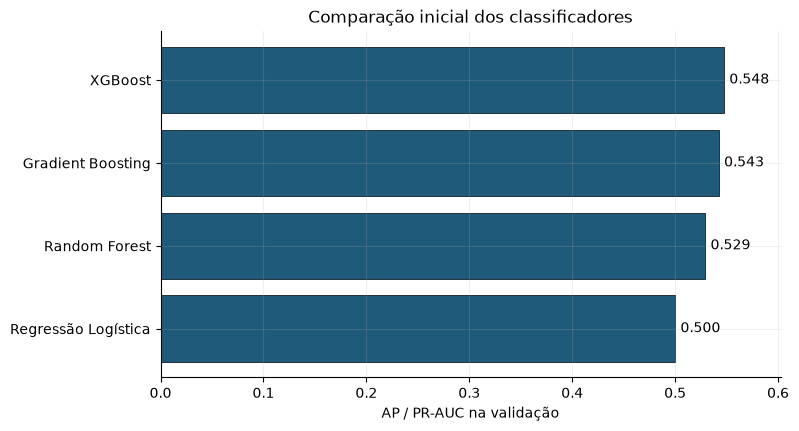

In [15]:
plot_data = benchmark_results.sort_values("AP_PR_AUC")
fig, ax = plt.subplots()
bars = ax.barh(plot_data["Modelo"], plot_data["AP_PR_AUC"], color=BLUE, edgecolor=CHARCOAL, linewidth=0.7)
ax.set_title("Comparação inicial dos classificadores")
ax.set_xlabel("AP / PR-AUC na validação")
ax.set_xlim(0, max(0.60, plot_data["AP_PR_AUC"].max() * 1.10))
for bar, value in zip(bars, plot_data["AP_PR_AUC"]):
    ax.text(value + 0.005, bar.get_y() + bar.get_height()/2, f"{value:.3f}", va="center")
plt.show()

In [16]:
gb_ap = float(benchmark_results.loc[benchmark_results["Modelo"] == "Gradient Boosting", "AP_PR_AUC"].iloc[0])
xgb_ap = float(benchmark_results.loc[benchmark_results["Modelo"] == "XGBoost", "AP_PR_AUC"].iloc[0])
rf_ap = float(benchmark_results.loc[benchmark_results["Modelo"] == "Random Forest", "AP_PR_AUC"].iloc[0])

benchmark_interpretation = pd.Series({
    "Random Forest vs. Logística (ganho AP)": rf_ap - float(benchmark_results.loc[benchmark_results["Modelo"] == "Regressão Logística", "AP_PR_AUC"].iloc[0]),
    "Gradient Boosting vs. Random Forest (ganho AP)": gb_ap - rf_ap,
    "XGBoost vs. Gradient Boosting (ganho AP)": xgb_ap - gb_ap,
    "Gradient Boosting / AP do XGBoost": gb_ap / xgb_ap,
})
benchmark_interpretation.to_frame("resultado")

,resultado
Random Forest vs. Logística (ganho AP),0.0292
Gradient Boosting vs. Random Forest (ganho AP),0.0132
XGBoost vs. Gradient Boosting (ganho AP),0.0051
Gradient Boosting / AP do XGBoost,0.9908


### Escolha do candidato para tuning

O `GradientBoostingClassifier` é o único candidato ao Optuna: deve ficar muito próximo do XGBoost, usa apenas scikit-learn e expõe hiperparâmetros claros (`n_estimators`, `learning_rate`, profundidade, amostragem e tamanho mínimo de folha). XGBoost permanece como comparação avançada, não como protagonista obrigatório.

## 7. Otimização com Optuna

A busca usa somente treino para `fit` e validação para retornar AP/PR-AUC. São 20 trials e cinco hiperparâmetros interpretáveis; o objetivo é demonstrar tuning, não perseguir o máximo global.

In [17]:
def optuna_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 80, 220, step=20),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 1, 4),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 40, step=5),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0, step=0.1),
    }
    trial_model = make_gradient_pipeline(params)
    trial_model.fit(X_train, y_train)
    validation_probabilities = trial_model.predict_proba(X_validation)[:, 1]
    return average_precision_score(y_validation, validation_probabilities)

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
tuning_started = time.perf_counter()
study.optimize(optuna_objective, n_trials=20, show_progress_bar=False)
tuning_seconds = time.perf_counter() - tuning_started

best_params = study.best_params
print(f"Melhor trial: {study.best_trial.number}")
print(f"Melhor AP/PR-AUC: {study.best_value:.6f}")
print(f"Tempo da busca: {tuning_seconds:.1f} s")
pd.Series(best_params, name="valor").to_frame()

Melhor trial: 14
Melhor AP/PR-AUC: 0.553862
Tempo da busca: 336.4 s


,valor
n_estimators,220.0000
learning_rate,0.0303
max_depth,4.0000
min_samples_leaf,35.0000
subsample,0.9000


In [18]:
trials_results = study.trials_dataframe(
    attrs=("number", "value", "params", "state")
).sort_values("value", ascending=False)
trials_results.head(10)

,number,value,params_learning_rate,params_max_depth,params_min_samples_leaf,params_n_estimators,params_subsample,state
14,14,0.5539,0.0303,4,35,220,0.9000,COMPLETE
12,12,0.5536,0.0303,4,35,220,0.9000,COMPLETE
18,18,0.5527,0.0454,4,30,180,1.0000,COMPLETE
1,1,0.5526,0.0329,4,25,100,0.9000,COMPLETE
11,11,0.5521,0.0305,4,30,220,0.9000,COMPLETE
13,13,0.5517,0.0303,4,35,120,0.9000,COMPLETE
16,16,0.5505,0.0369,2,35,200,1.0000,COMPLETE
9,9,0.5504,0.0495,3,25,180,0.7000,COMPLETE
5,5,0.5501,0.0414,3,25,200,0.7000,COMPLETE
0,0,0.5494,0.1386,3,25,120,0.7000,COMPLETE


In [19]:
tuned_model = make_gradient_pipeline(best_params)
tuned_started = time.perf_counter()
tuned_model.fit(X_train, y_train)
tuned_training_seconds = time.perf_counter() - tuned_started
tuned_validation_probabilities = tuned_model.predict_proba(X_validation)[:, 1]

tuned_row = metric_row(
    "Gradient Boosting otimizado",
    y_validation,
    tuned_validation_probabilities,
    training_seconds=tuned_training_seconds,
)
baseline_row = benchmark_results.loc[
    benchmark_results["Modelo"] == "Gradient Boosting"
].iloc[0].to_dict()

tuning_comparison = pd.DataFrame([
    {
        "Modelo": "Gradient Boosting inicial",
        **{key: baseline_row[key] for key in ["Precision", "Recall", "F1", "ROC_AUC", "AP_PR_AUC", "TN", "FP", "FN", "TP", "Tempo_treino_s"]},
    },
    tuned_row,
])
tuning_comparison["Ganho_AP_vs_inicial"] = tuning_comparison["AP_PR_AUC"] - tuning_comparison.iloc[0]["AP_PR_AUC"]
tuning_relative_gain = tuned_row["AP_PR_AUC"] / baseline_row["AP_PR_AUC"] - 1
print(f"Ganho relativo de AP: {tuning_relative_gain:.2%}")
tuning_comparison

Ganho relativo de AP: 2.08%


,Modelo,Precision,Recall,F1,ROC_AUC,AP_PR_AUC,TN,FP,FN,TP,Tempo_treino_s,Threshold,Ganho_AP_vs_inicial
0,Gradient Boosting inicial,0.6933,0.3595,0.4734,0.7796,0.5426,4462,211,850,477,11.6153,NaN,0.0000
1,Gradient Boosting otimizado,0.6838,0.3617,0.4731,0.7826,0.5539,4451,222,847,480,30.2733,0.5000,0.0113


**Leitura pedagógica:** a métrica probabilística pode melhorar sem que nenhuma classificação mude no threshold 0,5. Isso conecta naturalmente tuning, ranking probabilístico e a etapa seguinte de threshold.

## 8. Classes desbalanceadas

Compara-se o mesmo Gradient Boosting otimizado em três condições:

1. dados originais;
2. `SMOTENC` aplicado somente ao treino, preservando as três nominais;
3. pesos balanceados via `sample_weight`, recurso aceito pelo Gradient Boosting.

Validação e teste mantém a distribuição original.

In [20]:
imbalance_rows = []
imbalance_models = {}
imbalance_validation_probabilities = {}

# 1) Original otimizado (já treinado somente no treino)
original_model = tuned_model
original_probabilities = tuned_validation_probabilities
imbalance_rows.append(metric_row(
    "Original", y_validation, original_probabilities,
    training_seconds=tuned_training_seconds,
))
imbalance_models["Original"] = original_model
imbalance_validation_probabilities["Original"] = original_probabilities

# 2) SMOTENC somente no treino bruto, antes do one-hot
nominal_indices = [X_train.columns.get_loc(column) for column in NOMINAL_COLUMNS]
smote = SMOTENC(categorical_features=nominal_indices, random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
smote_model = make_gradient_pipeline(best_params)
smote_started = time.perf_counter()
smote_model.fit(X_train_smote, y_train_smote)
smote_seconds = time.perf_counter() - smote_started
smote_probabilities = smote_model.predict_proba(X_validation)[:, 1]
imbalance_rows.append(metric_row(
    "SMOTENC", y_validation, smote_probabilities,
    training_seconds=smote_seconds,
))
imbalance_models["SMOTENC"] = smote_model
imbalance_validation_probabilities["SMOTENC"] = smote_probabilities

# 3) Pesos calculados somente a partir do target de treino
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
weighted_model = make_gradient_pipeline(best_params)
weighted_started = time.perf_counter()
weighted_model.fit(X_train, y_train, model__sample_weight=sample_weights)
weighted_seconds = time.perf_counter() - weighted_started
weighted_probabilities = weighted_model.predict_proba(X_validation)[:, 1]
imbalance_rows.append(metric_row(
    "Pesos", y_validation, weighted_probabilities,
    training_seconds=weighted_seconds,
))
imbalance_models["Pesos"] = weighted_model
imbalance_validation_probabilities["Pesos"] = weighted_probabilities

imbalance_results = pd.DataFrame(imbalance_rows).sort_values("AP_PR_AUC", ascending=False).reset_index(drop=True)
print("Distribuição antes do SMOTENC:", y_train.value_counts().sort_index().to_dict())
print("Distribuição depois do SMOTENC:", pd.Series(y_train_smote).value_counts().sort_index().to_dict())
imbalance_results

Distribuição antes do SMOTENC: {0: 14018, 1: 3982}
Distribuição depois do SMOTENC: {0: 14018, 1: 14018}


,Modelo,Threshold,Precision,Recall,F1,ROC_AUC,AP_PR_AUC,TN,FP,FN,TP,Tempo_treino_s
0,Original,0.5000,0.6838,0.3617,0.4731,0.7826,0.5539,4451,222,847,480,30.2733
1,Pesos,0.5000,0.4707,0.6119,0.5321,0.7800,0.5538,3760,913,515,812,29.9230
2,SMOTENC,0.5000,0.5058,0.5237,0.5146,0.7654,0.5273,3994,679,632,695,52.6195


In [21]:
original_ap = float(imbalance_results.loc[imbalance_results["Modelo"] == "Original", "AP_PR_AUC"].iloc[0])
best_imbalance_row = imbalance_results.iloc[0]

# Regra definida antes de abrir o teste: complexidade só vence com ganho de AP > 0,005.
if best_imbalance_row["Modelo"] != "Original" and best_imbalance_row["AP_PR_AUC"] > original_ap + 0.005:
    selected_strategy = str(best_imbalance_row["Modelo"])
else:
    selected_strategy = "Original"

selected_model = imbalance_models[selected_strategy]
selected_validation_probabilities = imbalance_validation_probabilities[selected_strategy]
print(f"Estratégia selecionada: {selected_strategy}")
print("Critério: preservar a solução original se SMOTENC/pesos não agregarem > 0,005 de AP.")

Estratégia selecionada: Original
Critério: preservar a solução original se SMOTENC/pesos não agregarem > 0,005 de AP.


## 9. Threshold de decisão

A sequência é explícita: `predict_proba()` → probabilidade → threshold → classe. Primeiro são mostrados thresholds simples. Uma malha de 0,20 a 0,50 serve apenas para escolher um candidato pedagógico na validação.

In [22]:
def threshold_metrics(y_true, probabilities, threshold):
    row = metric_row("", y_true, probabilities, threshold=threshold)
    return {key: row[key] for key in ["Threshold", "Precision", "Recall", "F1", "FP", "FN", "TP", "TN"]}

simple_thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]
simple_threshold_results = pd.DataFrame([
    threshold_metrics(y_validation, selected_validation_probabilities, threshold)
    for threshold in simple_thresholds
])
simple_threshold_results

,Threshold,Precision,Recall,F1,FP,FN,TP,TN
0,0.5000,0.6838,0.3617,0.4731,222,847,480,4451
1,0.4500,0.6595,0.3926,0.4922,269,806,521,4404
2,0.4000,0.6311,0.4318,0.5128,335,754,573,4338
3,0.3500,0.5981,0.4800,0.5326,428,690,637,4245
4,0.3000,0.5462,0.5298,0.5379,584,624,703,4089


In [23]:
detailed_thresholds = np.round(np.arange(0.20, 0.501, 0.01), 2)
detailed_threshold_results = pd.DataFrame([
    threshold_metrics(y_validation, selected_validation_probabilities, threshold)
    for threshold in detailed_thresholds
])

# Objetivo ilustrativo: recall >= 0,55 e precision >= 0,45; escolhe-se o maior threshold elegível.
# Sem custos de FP/FN, este NÃO é um threshold de produção.
eligible_thresholds = detailed_threshold_results.query("Recall >= 0.55 and Precision >= 0.45")
if len(eligible_thresholds):
    candidate_threshold = float(eligible_thresholds.sort_values("Threshold", ascending=False).iloc[0]["Threshold"])
else:
    candidate_threshold = float(detailed_threshold_results.sort_values("F1", ascending=False).iloc[0]["Threshold"])

candidate_threshold_row = threshold_metrics(
    y_validation, selected_validation_probabilities, candidate_threshold
)
print(f"Threshold candidato: {candidate_threshold:.2f}")
pd.DataFrame([candidate_threshold_row])

Threshold candidato: 0.27


,Threshold,Precision,Recall,F1,FP,FN,TP,TN
0,0.2700,0.5210,0.5599,0.5398,683,584,743,3990


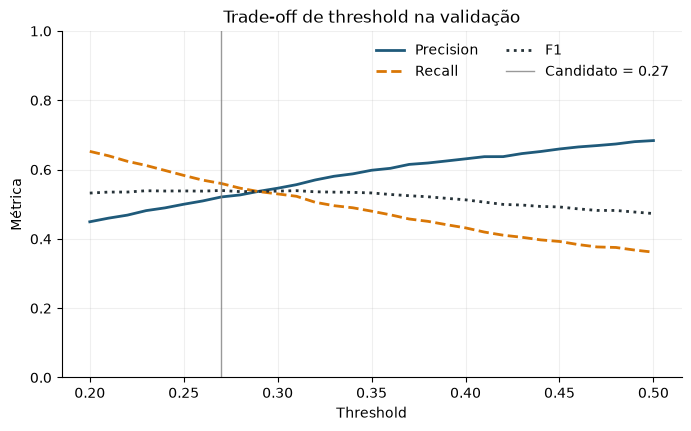

In [24]:
fig, ax = plt.subplots()
for metric, color, style in [
    ("Precision", BLUE, "-"),
    ("Recall", ORANGE, "--"),
    ("F1", CHARCOAL, ":"),
]:
    ax.plot(
        detailed_threshold_results["Threshold"],
        detailed_threshold_results[metric],
        label=metric,
        color=color,
        linestyle=style,
        linewidth=2,
    )
ax.axvline(candidate_threshold, color="grey", linewidth=1, alpha=0.8, label=f"Candidato = {candidate_threshold:.2f}")
ax.set_title("Trade-off de threshold na validação")
ax.set_xlabel("Threshold")
ax.set_ylabel("Métrica")
ax.set_ylim(0, 1)
ax.legend(frameon=False, ncol=2)
plt.show()

A escolha acima impõe pisos de recall e precision para tornar o compromisso explícito. Um custo real de falso positivo/falso negativo poderia — e provavelmente deveria — mudar esse threshold.

## 10. Experimento semi-supervisionado

Somente 25% dos rótulos de treino permanecem visíveis; 75% são marcados como `-1`. O baseline supervisionado usa exatamente a mesma parcela rotulada. Validação e teste nunca viram dados não rotulados.

In [25]:
train_positions = np.arange(len(X_train))
labeled_positions, unlabeled_positions = train_test_split(
    train_positions,
    train_size=0.25,
    stratify=y_train.to_numpy(),
    random_state=RANDOM_STATE,
)

X_train_array = X_train.to_numpy()
X_validation_array = X_validation.to_numpy()
y_train_array = y_train.to_numpy()
semi_labels = np.full(len(y_train_array), -1, dtype=int)
semi_labels[labeled_positions] = y_train_array[labeled_positions]

nominal_position_indices = [X_train.columns.get_loc(column) for column in NOMINAL_COLUMNS]
other_position_indices = [
    index for index in range(X_train.shape[1]) if index not in nominal_position_indices
]
semi_preprocessor = ColumnTransformer(
    transformers=[
        ("nominal", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal_position_indices),
        ("numeric_ordinal", StandardScaler(), other_position_indices),
    ],
)

def make_semi_logistic_pipeline():
    return Pipeline([
        ("preprocess", clone(semi_preprocessor)),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])

supervised_partial = make_semi_logistic_pipeline()
started = time.perf_counter()
supervised_partial.fit(X_train_array[labeled_positions], y_train_array[labeled_positions])
supervised_partial_seconds = time.perf_counter() - started
supervised_partial_probabilities = supervised_partial.predict_proba(X_validation_array)[:, 1]

self_training = SelfTrainingClassifier(
    estimator=make_semi_logistic_pipeline(),
    criterion="threshold",
    threshold=0.90,
    max_iter=10,
)
started = time.perf_counter()
self_training.fit(X_train_array, semi_labels)
self_training_seconds = time.perf_counter() - started
self_training_probabilities = self_training.predict_proba(X_validation_array)[:, 1]

semi_supervised_results = pd.DataFrame([
    metric_row("Supervisionado — 25% rotulado", y_validation, supervised_partial_probabilities, training_seconds=supervised_partial_seconds),
    metric_row("Self-training", y_validation, self_training_probabilities, training_seconds=self_training_seconds),
])
semi_supervised_results

,Modelo,Threshold,Precision,Recall,F1,ROC_AUC,AP_PR_AUC,TN,FP,FN,TP,Tempo_treino_s
0,Supervisionado — 25% rotulado,0.5000,0.7205,0.2389,0.3588,0.7245,0.4946,4550,123,1010,317,0.0844
1,Self-training,0.5000,0.6943,0.2585,0.3767,0.7244,0.4907,4522,151,984,343,1.3388


In [26]:
added_mask = (semi_labels == -1) & (self_training.transduction_ != -1)
remaining_mask = self_training.transduction_ == -1
pseudo_labels = self_training.transduction_[added_mask]
true_hidden_labels = y_train_array[added_mask]

pseudo_label_audit = pd.Series({
    "Rótulos iniciais": len(labeled_positions),
    "Rótulos ocultados": len(unlabeled_positions),
    "Pseudorrótulos adicionados": int(added_mask.sum()),
    "Ainda não rotulados": int(remaining_mask.sum()),
    "Pseudorrótulos classe 0": int((pseudo_labels == 0).sum()),
    "Pseudorrótulos classe 1": int((pseudo_labels == 1).sum()),
    "Acurácia dos pseudorrótulos no cenário artificial": float((pseudo_labels == true_hidden_labels).mean()),
    "Iterações": int(self_training.n_iter_),
})
pseudo_label_audit.to_frame("resultado")

,resultado
Rótulos iniciais,"4,500.0000"
Rótulos ocultados,"13,500.0000"
Pseudorrótulos adicionados,"6,728.0000"
Ainda não rotulados,"6,772.0000"
Pseudorrótulos classe 0,"6,649.0000"
Pseudorrótulos classe 1,79.0000
Acurácia dos pseudorrótulos no cenário artificial,0.8769
Iterações,10.0000


In [27]:
self_training_ap = float(semi_supervised_results.loc[semi_supervised_results["Modelo"] == "Self-training", "AP_PR_AUC"].iloc[0])
supervised_partial_ap = float(semi_supervised_results.loc[semi_supervised_results["Modelo"] == "Supervisionado — 25% rotulado", "AP_PR_AUC"].iloc[0])
self_training_recommendation = "SIM" if self_training_ap >= supervised_partial_ap + 0.005 else "APENAS DEMONSTRAÇÃO"
print(f"Recomendação semi-supervisionada: {self_training_recommendation}")
print(f"Delta de AP: {self_training_ap - supervised_partial_ap:+.6f}")

Recomendação semi-supervisionada: APENAS DEMONSTRAÇÃO
Delta de AP: -0.003967


## 11. Interpretação

São usadas duas leituras nativas: `feature_importances_` no espaço transformado e Permutation Importance nas 23 features originais, sobre a validação e com AP/PR-AUC. Importância preditiva não implica causa da inadimplência.

In [28]:
transformed_feature_names = selected_model.named_steps["preprocess"].get_feature_names_out()
transformed_importances = selected_model.named_steps["model"].feature_importances_
feature_importance_table = (
    pd.DataFrame({
        "feature_transformada": transformed_feature_names,
        "importância": transformed_importances,
    })
    .sort_values("importância", ascending=False)
    .reset_index(drop=True)
)
feature_importance_table.head(15)

,feature_transformada,importância
0,PAY_0,0.5809
1,PAY_2,0.0707
2,BILL_AMT1,0.0465
3,PAY_3,0.0428
4,LIMIT_BAL,0.0388
5,PAY_AMT2,0.0256
6,PAY_AMT3,0.0234
7,PAY_AMT1,0.0231
8,AGE,0.0157
9,PAY_5,0.0155


In [29]:
permutation_started = time.perf_counter()
permutation_result = permutation_importance(
    selected_model,
    X_validation,
    y_validation,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
permutation_seconds = time.perf_counter() - permutation_started
permutation_table = (
    pd.DataFrame({
        "feature": feature_columns,
        "importância_média": permutation_result.importances_mean,
        "desvio": permutation_result.importances_std,
    })
    .sort_values("importância_média", ascending=False)
    .reset_index(drop=True)
)
print(f"Tempo da Permutation Importance: {permutation_seconds:.1f} s")
permutation_table.head(15)

Tempo da Permutation Importance: 9.1 s


,feature,importância_média,desvio
0,PAY_0,0.1855,0.0075
1,LIMIT_BAL,0.0166,0.0021
2,PAY_2,0.0150,0.0012
3,BILL_AMT1,0.0126,0.0037
4,PAY_3,0.0095,0.0027
5,PAY_AMT3,0.0073,0.0013
6,PAY_4,0.0046,0.0009
7,PAY_AMT1,0.0042,0.0018
8,PAY_5,0.0039,0.0009
9,PAY_6,0.0033,0.0015


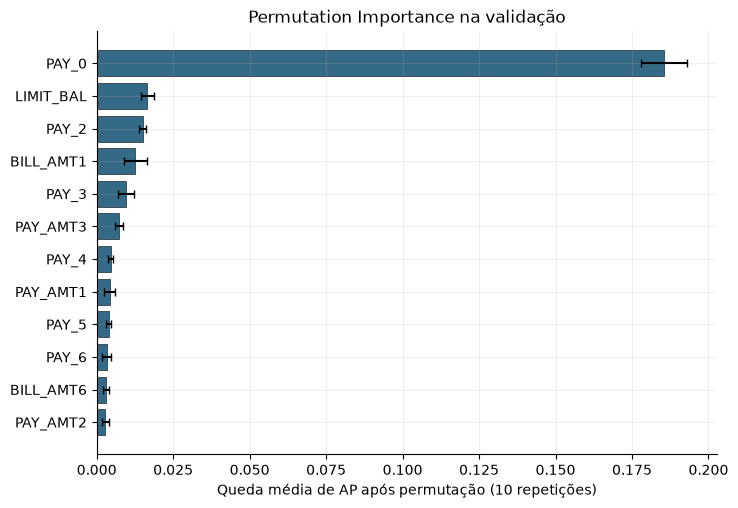

In [30]:
top_permutation = permutation_table.head(12).sort_values("importância_média")
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(
    top_permutation["feature"],
    top_permutation["importância_média"],
    xerr=top_permutation["desvio"],
    color=BLUE,
    alpha=0.9,
    edgecolor=CHARCOAL,
    linewidth=0.6,
    capsize=3,
)
ax.axvline(0, color=CHARCOAL, linewidth=0.8)
ax.set_title("Permutation Importance na validação")
ax.set_xlabel("Queda média de AP após permutação (10 repetições)")
plt.show()

Features mensais correlacionadas podem dividir importância entre si. Valores próximos de zero não provam irrelevância de negócio; medem apenas o efeito marginal da permutação neste modelo e nesta validação.

## 12. Congelamento das decisóes

A partir desta célula ficam congelados modelo, hiperparâmetros, estratégia de balanceamento, threshold e preprocessing. O modelo não é reajustado com validação, para manter a comparação validação versus teste diretamente interpretável.

In [31]:
selected_validation_row = metric_row(
    f"Validação — {selected_strategy}",
    y_validation,
    selected_validation_probabilities,
    threshold=candidate_threshold,
)

frozen_decisions = {
    "modelo": "GradientBoostingClassifier",
    "hiperparâmetros": best_params,
    "preprocessing": "one-hot em SEX/EDUCATION/MARRIAGE; PAY_* ordinal; sem escala para árvores",
    "balanceamento": selected_strategy,
    "threshold": candidate_threshold,
    "métrica_de_seleção": "Average Precision (AP/PR-AUC)",
    "refit_com_validação": False,
}
decisions_frozen = True
assert test_is_locked is True
pd.Series(frozen_decisions, name="decisão").to_frame()

,decisão
modelo,GradientBoostingClassifier
hiperparâmetros,"{'n_estimators': 220, 'learning_rate': 0.03032..."
preprocessing,one-hot em SEX/EDUCATION/MARRIAGE; PAY_* ordin...
balanceamento,Original
threshold,0.2700
métrica_de_seleção,Average Precision (AP/PR-AUC)
refit_com_validação,False


## 13. Avaliação final única no teste

Esta é a primeira e única chamada a `predict_proba()` no teste. Nenhuma decisão será alterada depois deste resultado.

In [32]:
assert decisions_frozen is True
assert test_is_locked is True

test_evaluation_count = 0
test_probabilities = selected_model.predict_proba(X_test)[:, 1]
test_evaluation_count += 1
final_test_row = metric_row(
    "Teste final",
    y_test,
    test_probabilities,
    threshold=candidate_threshold,
)
test_is_locked = False
assert test_evaluation_count == 1

final_comparison = pd.DataFrame([
    selected_validation_row,
    final_test_row,
])
final_comparison["Conjunto"] = ["Validação", "Teste"]
final_comparison[
    ["Conjunto", "Threshold", "Precision", "Recall", "F1", "ROC_AUC", "AP_PR_AUC", "TN", "FP", "FN", "TP"]
]

,Conjunto,Threshold,Precision,Recall,F1,ROC_AUC,AP_PR_AUC,TN,FP,FN,TP
0,Validação,0.2700,0.5210,0.5599,0.5398,0.7826,0.5539,3990,683,584,743
1,Teste,0.2700,0.5252,0.5569,0.5406,0.7778,0.5543,4005,668,588,739


In [33]:
final_confusion_matrix = pd.DataFrame(
    [[final_test_row["TN"], final_test_row["FP"]], [final_test_row["FN"], final_test_row["TP"]]],
    index=["Real 0", "Real 1"],
    columns=["Predito 0", "Predito 1"],
)
final_confusion_matrix

,Predito 0,Predito 1
Real 0,4005,668
Real 1,588,739


In [34]:
generalization_gaps = pd.Series({
    metric: final_test_row[metric] - selected_validation_row[metric]
    for metric in ["Precision", "Recall", "F1", "ROC_AUC", "AP_PR_AUC"]
}, name="teste_menos_validação")
generalization_gaps.to_frame()

,teste_menos_validação
Precision,0.0042
Recall,-0.0030
F1,0.0008
ROC_AUC,-0.0048
AP_PR_AUC,0.0004


## Viabilidade da aplicação final

O objeto selecionado contém preprocessing e modelo. O payload acrescenta threshold e ordem das features. A serialização abaixo ocorre apenas em memória; nenhum modelo definitivo é salvo nesta fase.

In [35]:
model_payload = {
    "pipeline": selected_model,
    "threshold": candidate_threshold,
    "feature_columns": feature_columns,
    "target": TARGET,
    "versions": versions.to_dict(),
}
model_buffer = BytesIO()
joblib.dump(model_payload, model_buffer)
serialized_size_mb = model_buffer.tell() / (1024 ** 2)
model_buffer.seek(0)
restored_payload = joblib.load(model_buffer)

sample_clients = X_validation.iloc[:5]
original_sample_probabilities = selected_model.predict_proba(sample_clients)[:, 1]
restored_sample_probabilities = restored_payload["pipeline"].predict_proba(sample_clients)[:, 1]
assert np.allclose(original_sample_probabilities, restored_sample_probabilities)

application_example = pd.DataFrame({
    "probabilidade_inadimplência": restored_sample_probabilities,
    "threshold": restored_payload["threshold"],
    "classe": (restored_sample_probabilities >= restored_payload["threshold"]).astype(int),
}, index=sample_clients.index)
print(f"Payload serializado em memória: {serialized_size_mb:.2f} MB")
application_example

Payload serializado em memória: 0.45 MB


,probabilidade_inadimplência,threshold,classe
18316,0.2177,0.2700,0
1482,0.0823,0.2700,0
10396,0.2436,0.2700,0
9360,0.0728,0.2700,0
18144,0.0909,0.2700,0


Fluxo futuro comprovado: dados do cliente → preprocessing → `predict_proba()` → probabilidade → threshold congelado → classe. Falta apenas construir a interface; isso está fora do escopo desta fase.

## 14. Conclusóes pedagógicas

In [36]:
xgb_gain_over_gb = xgb_ap - gb_ap
smote_ap = float(imbalance_results.loc[imbalance_results["Modelo"] == "SMOTENC", "AP_PR_AUC"].iloc[0])
weights_ap = float(imbalance_results.loc[imbalance_results["Modelo"] == "Pesos", "AP_PR_AUC"].iloc[0])
weights_recall = float(imbalance_results.loc[imbalance_results["Modelo"] == "Pesos", "Recall"].iloc[0])
original_recall = float(imbalance_results.loc[imbalance_results["Modelo"] == "Original", "Recall"].iloc[0])
top_features = permutation_table.head(8)["feature"].tolist()

pedagogical_recommendations = pd.DataFrame([
    ("1. Random Forest funciona para Bagging?", "SIM", f"AP {rf_ap:.3f}; supera a logística e mantém implementação simples."),
    ("2. Gradient Boosting funciona para Boosting?", "SIM", f"AP inicial {gb_ap:.3f} e melhor F1 do benchmark inicial."),
    ("3. XGBoost agrega valor?", "SIM, COMO COMPARAÇÃO", f"Ganho sobre GB inicial de apenas {xgb_gain_over_gb:+.4f} AP."),
    ("4. XGBoost domina o projeto?", "NÃO", f"GB entrega {gb_ap/xgb_ap:.2%} da AP do XGBoost antes do tuning."),
    ("5. Qual modelo otimizar?", "GRADIENT BOOSTING", f"Optuna elevou AP em {tuning_relative_gain:.2%} relativo com hiperparâmetros ensináveis."),
    ("6. SMOTE vale a pena?", "NÃO COMO MODELO FINAL", f"SMOTENC AP {smote_ap:.3f} versus original {original_ap:.3f}."),
    ("7. Pesos valem a pena?", "SIM COMO TRADE-OFF", f"Recall {original_recall:.3f} → {weights_recall:.3f}; AP ficou {weights_ap:.3f}."),
    ("8. Threshold é uma boa demonstração?", "SIM", f"Candidato {candidate_threshold:.2f}; altera FP/FN de forma visível."),
    ("9. Self-training?", self_training_recommendation, f"Delta AP {self_training_ap-supervised_partial_ap:+.6f}; forte viés para pseudorrótulos 0."),
    ("10. Permutation Importance funciona?", "SIM, COM CAVEATS", ", ".join(top_features[:5]) + "; importância não é causal."),
    ("11. Modelo para a aplicação?", f"GB OTIMIZADO — {selected_strategy.upper()}", f"Pipeline serializável com threshold {candidate_threshold:.2f}."),
    ("12. Cabe em seis aulasó", "SIM, COM PODA", "Self-training deve ser curto; XGBoost não precisa ser protagonista."),
    ("13. Complexidade removível?", "SIM", "Sem engenharia extensa, SHAP/LIME, grids grandes ou múltiplos balanceadores."),
], columns=["pergunta", "resposta", "evidência"])
pedagogical_recommendations

,pergunta,resposta,evidência
0,1. Random Forest funciona para Bagging?,SIM,AP 0.529; supera a logística e mantém implemen...
1,2. Gradient Boosting funciona para Boosting?,SIM,AP inicial 0.543 e melhor F1 do benchmark inic...
2,3. XGBoost agrega valor?,"SIM, COMO COMPARAÇÃO",Ganho sobre GB inicial de apenas +0.0051 AP.
3,4. XGBoost domina o projeto?,NÃO,GB entrega 99.08% da AP do XGBoost antes do tu...
4,5. Qual modelo otimizar?,GRADIENT BOOSTING,Optuna elevou AP em 2.08% relativo com hiperpa...
5,6. SMOTE vale a pena?,NÃO COMO MODELO FINAL,SMOTENC AP 0.527 versus original 0.554.
6,7. Pesos valem a pena?,SIM COMO TRADE-OFF,Recall 0.362 → 0.612; AP ficou 0.554.
7,8. Threshold é uma boa demonstração?,SIM,Candidato 0.27; altera FP/FN de forma visível.
8,9. Self-training?,APENAS DEMONSTRAÇÃO,Delta AP -0.003967; forte viés para pseudorrót...
9,10. Permutation Importance funciona?,"SIM, COM CAVEATS","PAY_0, LIMIT_BAL, PAY_2, BILL_AMT1, PAY_3; imp..."


In [37]:
summary_payload = {
    "data": {
        "rows": int(len(data)),
        "columns": int(data.shape[1]),
        "positive_rate": float(y.mean()),
        "missing_cells": missing_cells,
        "exact_duplicates": exact_duplicates,
        "sha256": raw_sha256,
    },
    "split": split_summary.to_dict(orient="records"),
    "benchmark": benchmark_results[["Modelo", "Precision", "Recall", "F1", "ROC_AUC", "AP_PR_AUC", "Tempo_treino_s"]].to_dict(orient="records"),
    "tuning": {
        "best_trial": int(study.best_trial.number),
        "best_params": best_params,
        "baseline_ap": float(baseline_row["AP_PR_AUC"]),
        "tuned_ap": float(tuned_row["AP_PR_AUC"]),
        "relative_gain": float(tuning_relative_gain),
        "search_seconds": float(tuning_seconds),
    },
    "imbalance": imbalance_results[["Modelo", "Precision", "Recall", "F1", "ROC_AUC", "AP_PR_AUC", "FP", "FN"]].to_dict(orient="records"),
    "selected_strategy": selected_strategy,
    "candidate_threshold": float(candidate_threshold),
    "threshold_points": simple_threshold_results.to_dict(orient="records"),
    "self_training": {
        "recommendation": self_training_recommendation,
        "supervised_ap": supervised_partial_ap,
        "self_training_ap": self_training_ap,
        "pseudo_labels_added": int(added_mask.sum()),
        "pseudo_positive_share": float((pseudo_labels == 1).mean()),
    },
    "permutation_top": permutation_table.head(10).to_dict(orient="records"),
    "validation_final": selected_validation_row,
    "test_final": final_test_row,
    "versions": versions.to_dict(),
}
print("Resumo técnico consolidado; consulte as tabelas e o tl;dr acima.")

Resumo técnico consolidado; consulte as tabelas e o tl;dr acima.
